In [2]:
import pickle
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import librosa.display as dsp
from google.colab import files
import os
import json

# ===== 1. HÀM LOAD MODEL (ĐÃ SỬA LẠI CHO ĐÚNG) =====
def load_model_from_directory(load_path):
    """
    Tải mô hình HMM, scaler và class_names từ một THƯ MỤC.
    (Hàm này tương thích với hàm save_model đã thống nhất)
    """
    print(f"📂 Đang tải mô hình từ thư mục: {load_path}")

    # Kiểm tra thư mục tồn tại
    if not os.path.exists(load_path):
        raise FileNotFoundError(f"Không tìm thấy thư mục: {load_path}")

    # 1. Tải models (danh sách các object)
    models_path = os.path.join(load_path, 'models.pkl')
    with open(models_path, 'rb') as f:
        models = pickle.load(f)
    print(f"✅ Đã tải {len(models)} models (dạng list) từ: {models_path}")

    # 2. Tải scaler
    scaler_path = os.path.join(load_path, 'scaler.pkl')
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
    print(f"✅ Đã tải scaler từ: {scaler_path}")

    # 3. Tải class_names (từ summary.json)
    summary_path = os.path.join(load_path, 'summary.json')
    if not os.path.exists(summary_path):
        raise FileNotFoundError(f"Không tìm thấy file summary.json tại: {summary_path}")

    with open(summary_path, 'r', encoding='utf-8') as f:
        summary = json.load(f)
    class_names = summary['class_names']
    print(f"✅ Đã tải class_names ({class_names}) từ: {summary_path}")

    return models, class_names, scaler

# ===== 2. HÀM VẼ BIỂU ĐỒ (TÁCH BIỆT) =====
def plot_results(audio_file_path, y, sr, mfcc_scaled, predicted_class, confidence):
    """Vẽ biểu đồ waveform và MFCC cho kết quả dự đoán."""
    plt.figure(figsize=(12, 6))

    # Subplot 1: Waveform
    plt.subplot(2, 1, 1)
    dsp.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f'Waveform - Predicted: {predicted_class} (Confidence: {confidence:.1%})')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')

    # Subplot 2: MFCC
    plt.subplot(2, 1, 2)
    # Giả sử hop_length=256 khi trích xuất
    dsp.specshow(mfcc_scaled.T, sr=sr, hop_length=256, x_axis='time', cmap='coolwarm')
    plt.colorbar(format='%+2.0f')
    plt.title('MFCC Features (Normalized)')
    plt.xlabel('Time (s)')
    plt.ylabel('MFCC Coefficients')

    plt.tight_layout()
    plt.show()

# ===== 3. HÀM DỰ ĐOÁN & HIỂN THỊ (GỘP LẠI) =====
def predict_and_display_results(audio_file_path, models, scaler, class_names):
    """
    Hàm chính: Trích xuất feature, dự đoán, và hiển thị tất cả kết quả.
    """

    # 1. Trích xuất features
    print(f"\nĐang trích xuất features từ: {audio_file_path}...")
    mfcc_features = extract_features(audio_file_path)

    if mfcc_features is None:
        print("❌ Không thể trích xuất features từ file này!")
        return

    print(f"📊 Shape của MFCC features (raw): {mfcc_features.shape}")

    # 2. Chuẩn hóa (Scaling)
    mfcc_features_scaled = scaler.transform(mfcc_features)
    print(f"📊 Shape sau chuẩn hóa: {mfcc_features_scaled.shape}")

    # 3. Đọc audio để phát và vẽ biểu đồ
    y, sr = librosa.load(audio_file_path, sr=22050)
    print("\n🔊 Phát audio:")
    display(Audio(y, rate=sr))

    # 4. Dự đoán bằng HMM
    print("\n📈 Tính toán log probability cho mỗi class:")
    log_probs = []
    for i, model in enumerate(models):
        if model is None: # Xử lý trường hợp lớp không có data lúc train
            log_probs.append(-np.inf)
            print(f"   Class {class_names[i]}: Bỏ qua (không có model)")
        else:
            log_prob = model.forward(mfcc_features_scaled)[0]
            log_probs.append(log_prob)
            print(f"   Class {class_names[i]}: log_prob = {log_prob:.2f}")

    # 5. Tính toán kết quả
    predicted_idx = int(np.argmax(log_probs))
    predicted_class = class_names[predicted_idx]

    # Tính confidence (xác suất tương đối)
    log_probs_arr = np.array(log_probs)
    probs_normalized = np.exp(log_probs_arr - np.max(log_probs_arr))
    probs_normalized /= probs_normalized.sum()
    confidence = probs_normalized[predicted_idx]

    # 6. Hiển thị kết quả dạng text
    print("\n" + "="*60)
    print(f"🎯 KẾT QUẢ DỰ ĐOÁN")
    print("="*60)
    print(f"   Số dự đoán: {predicted_class}")
    print(f"   Độ tin cậy: {confidence:.2%}")
    print("="*60)

    print("\n📊 Phân phối xác suất:")
    for i, class_name in enumerate(class_names):
        bar = "█" * int(probs_normalized[i] * 50)
        print(f"   {class_name}: {probs_normalized[i]:>6.1%} {bar}")

    # 7. Vẽ biểu đồ
    plot_results(audio_file_path, y, sr, mfcc_features_scaled, predicted_class, confidence)


In [4]:
import sys # Add this line to import the sys module

# 1. Quay về thư mục gốc của Colab để đảm bảo vị trí đúng
%cd /content

# 2. Xóa thư mục dự án cũ đi nếu nó tồn tại (đây chính là bước "ghi đè")
PROJECT_DIR = 'project_dir'
if os.path.exists(PROJECT_DIR):
    print(f"Thư mục '{PROJECT_DIR}' đã tồn tại. Đang xóa để ghi đè...")
    !rm -rf {PROJECT_DIR}

# 3. Tạo lại thư mục dự án và di chuyển vào đó
print(f"Tạo thư mục mới '{PROJECT_DIR}'...")
!mkdir {PROJECT_DIR}
%cd {PROJECT_DIR}

# 4. Khởi tạo git và tải code bằng sparse checkout
print("Đang tải code từ GitHub...")
!git init
!git remote add origin https://github.com/ChiThanh512/Machine-Learning-Project-251---CEML1.git
!git config core.sparsecheckout true
!echo "HPMR/" >> .git/info/sparse-checkout
!git pull origin main

# 5. Kiểm tra kết quả
print("\n--- Cấu trúc thư mục sau khi tải: ---")
!ls -R
# Thêm đường dẫn đến thư mục HPMR vào sys.path
hpmr_path = os.path.abspath('HPMR')
if hpmr_path not in sys.path:
    sys.path.append(hpmr_path)
    print(f"Đã thêm '{hpmr_path}' vào sys.path")

/content
Thư mục 'project_dir' đã tồn tại. Đang xóa để ghi đè...
Tạo thư mục mới 'project_dir'...
/content/project_dir
Đang tải code từ GitHub...
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/project_dir/.git/
remote: Enumerating objects: 794, done.
remote: Counting objects: 100% (279/279), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 794 (delta 147), reused 188 (delta 84), pack-reused 515 (from 3)
Receiving objects: 100% (794/794), 170.46 MiB | 27.00 MiB/s, done.
Resolving deltas: 100

📂 Đang tải mô hình từ thư mục: ./HPMR/models/hmm_model_1
✅ Đã tải 10 models (dạng list) từ: ./HPMR/models/hmm_model_1/models.pkl
✅ Đã tải scaler từ: ./HPMR/models/hmm_model_1/scaler.pkl
✅ Đã tải class_names (['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']) từ: ./HPMR/models/hmm_model_1/summary.json

📂 Vui lòng upload file WAV của bạn:


Saving test1.wav to test1.wav

🎵 File được upload: test1.wav

Đang trích xuất features từ: test1.wav...
📊 Shape của MFCC features (raw): (39, 39)
📊 Shape sau chuẩn hóa: (39, 39)

🔊 Phát audio:



📈 Tính toán log probability cho mỗi class:
   Class zero: log_prob = -2173.38
   Class one: log_prob = -2390.70
   Class two: log_prob = -2267.09
   Class three: log_prob = -2503.92
   Class four: log_prob = -2330.11
   Class five: log_prob = -2490.04
   Class six: log_prob = -2653.44
   Class seven: log_prob = -2404.38
   Class eight: log_prob = -2482.99
   Class nine: log_prob = -2304.22

🎯 KẾT QUẢ DỰ ĐOÁN
   Số dự đoán: zero
   Độ tin cậy: 100.00%

📊 Phân phối xác suất:
   zero: 100.0% ██████████████████████████████████████████████████
   one:   0.0% 
   two:   0.0% 
   three:   0.0% 
   four:   0.0% 
   five:   0.0% 
   six:   0.0% 
   seven:   0.0% 
   eight:   0.0% 
   nine:   0.0% 


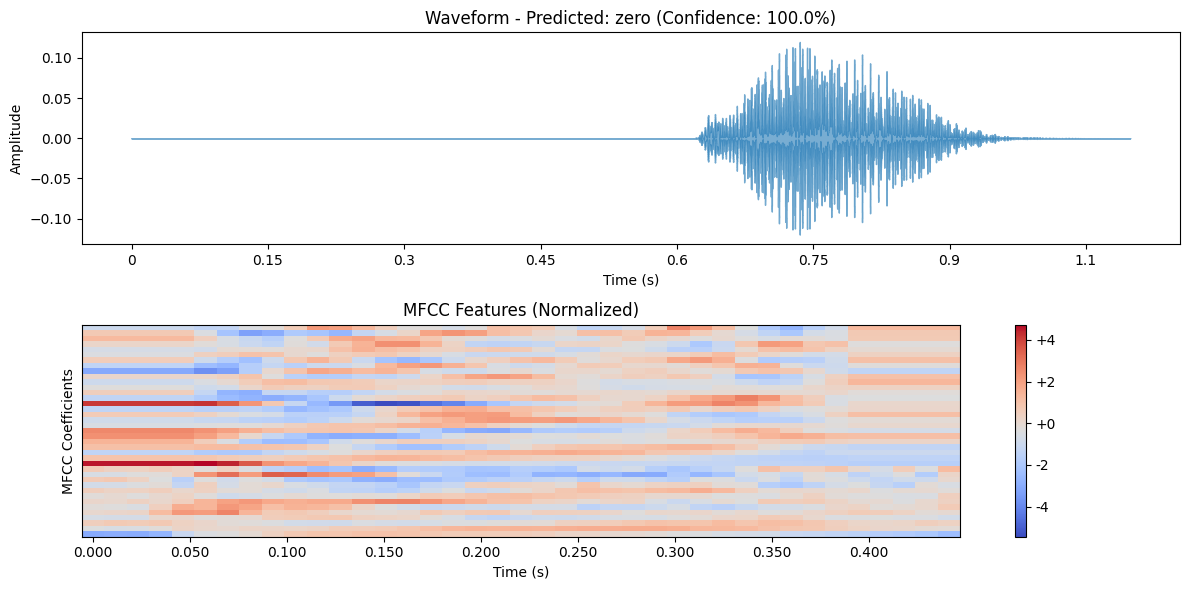

In [12]:
from modules.HMM import continueHMM
from modules.preprocessing import extract_features
try:
    model_directory_path = './HPMR/models/hmm_model_1'

    models_loaded, class_names_loaded, scaler = load_model_from_directory(model_directory_path)

    # 4.2. Upload file
    print("\n📂 Vui lòng upload file WAV của bạn:")
    uploaded = files.upload()
    audio_file = list(uploaded.keys())[0]
    print(f"\n🎵 File được upload: {audio_file}")

    # 4.3. Chạy toàn bộ quá trình
    predict_and_display_results(audio_file, models_loaded, scaler, class_names_loaded)

except FileNotFoundError as e:
    print(f"❌ LỖI: {e}")
    print("👉 Vui lòng kiểm tra lại biến 'model_directory_path'.")
except Exception as e:
    print(f"Một lỗi không xác định đã xảy ra: {e}")